# Advanced Image Classification with ImageNet

In this assignment, you will be asked to develop a convolutional neural network (CNN) to classify images from the CIFAR-100 dataset. At each step, you'll be guided through the process of developing a model architecture to solve a problem. Your goal is to create a CNN that attains at least 55% accuracy on the validation set.

### The CIFAR-100 Dataset

The [CIFAR-100 dataset](https://www.cs.toronto.edu/~kriz/cifar.html) consists of 60000 32x32 colour images in 100 classes, with 600 images per class. There are 50000 training images and 10000 test images. The dataset is divided into five training batches and one test batch, each with 10000 images. The test batch contains exactly 1000 randomly-selected images from each class. The training batches contain the remaining images in random order, but some training batches may contain more images from one class than another. Between them, the training batches contain exactly 500 images from each class.

### Tools

You will use Keras with TensorFlow to develop your CNN. For this assignment, it's strongly recommended that you use a GPU to accelerate your training, or else you might find it difficult to train your network in a reasonable amount of time. If you have a computer with a GPU that you wish to use, you can follow the [TensorFlow instructions](https://www.tensorflow.org/install/) for installing TensorFlow with GPU support. Otherwise, you can use [Google Colab](https://colab.research.google.com/) to complete this assignment. Colab provides free access to GPU-enabled machines. If you run into any issues, please contact us as soon as possible so that we can help you resolve them.

## Task 1: Data Exploration and Preprocessing (Complete or Incomplete)
### 1a: Load and Explore the Dataset
- Use the code below to download the dataset.
- Explore the dataset: examine the shape of the training and test sets, the dimensions of the images, and the number of classes. Show a few examples from the training set.

In [4]:
import tensorflow as tf
print(tf.__version__)
from tensorflow import keras

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split



2.18.0


In [5]:
from keras.datasets import cifar100

# Load the CIFAR-100 dataset
(x_train, y_train), (x_test, y_test) = cifar100.load_data(label_mode='fine')

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [6]:
class_names = [
    "apple", "aquarium_fish", "baby", "bear", "beaver", "bed", "bee", "beetle", "bicycle", "bottle",
    "bowl", "boy", "bridge", "bus", "butterfly", "camel", "can", "castle", "caterpillar", "cattle",
    "chair", "chimpanzee", "clock", "cloud", "cockroach", "couch", "crab", "crocodile", "cup", "dinosaur",
    "dolphin", "elephant", "flatfish", "forest", "fox", "girl", "hamster", "house", "kangaroo", "keyboard",
    "lamp", "lawn_mower", "leopard", "lion", "lizard", "lobster", "man", "maple_tree", "motorcycle", "mountain",
    "mouse", "mushroom", "oak_tree", "orange", "orchid", "otter", "palm_tree", "pear", "pickup_truck", "pine_tree",
    "plain", "plate", "poppy", "porcupine", "possum", "rabbit", "raccoon", "ray", "road", "rocket",
    "rose", "sea", "seal", "shark", "shrew", "skunk", "skyscraper", "snail", "snake", "spider",
    "squirrel", "streetcar", "sunflower", "sweet_pepper", "table", "tank", "telephone", "television", "tiger", "tractor",
    "train", "trout", "tulip", "turtle", "wardrobe", "whale", "willow_tree", "wolf", "woman", "worm"
]

The shape of training data is (50000, 32, 32, 3) and test data set is (10000, 32, 32, 3) 
Unique number of classes are 100


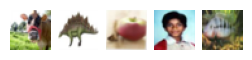

In [7]:
# Display the shape and number of classes
print(f'The shape of training data is {x_train.shape} and test data set is {x_test.shape} ')
print(f'Unique number of classes are {len(np.unique(y_train))}')

# Display some examples from the training dataset
fig, axes = plt.subplots(1, 5, figsize=(3, 3))
for i in range(5):
    axes[i].imshow(x_train[i])
    axes[i].axis("off")
plt.show()



### 1b: Data Preprocessing
- With the data downloaded, it's time to preprocess it. Start by normalizing the images so that they all have pixel values in the range [0, 1].
- Next, convert the labels to one-hot encoded vectors.
- Finally, split the training set into training and validation sets. Use 80% of the training set for training and the remaining 20% for validation.

In [8]:
#Find the current dataset pixel value ranges
print("Training and test dataset current pixel value range:")
print(f"Training dataset Min: {np.min(x_train)} and Max: {np.max(x_train)}")
print(f"Test dataset Min: {np.min(x_test)} and Max: {np.max(x_test)}")


Training and test dataset current pixel value range:
Training dataset Min: 0 and Max: 255
Test dataset Min: 0 and Max: 255


In [9]:
from tensorflow.keras.utils import to_categorical

# Normalize the images in the range [0,1]
x_train = x_train.astype('float32')/255.0
x_test = x_test.astype('float32')/255.0

print(f'Before one-hot encoding: {y_train[0]}')
y_train = to_categorical(y_train, num_classes=len(np.unique(y_train)))
y_test = to_categorical(y_test, num_classes=len(np.unique(y_test)))
print(f'After one-hot encoding: {y_train[0]}')

#split the training set into training and validation datasets
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42)

# Display the shape of training and validation data sets
print(f'The shape of training data is {x_train.shape}, {y_train.shape} and validation data set is {x_val.shape}, {y_val.shape} ')



Before one-hot encoding: [19]
After one-hot encoding: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0.]
The shape of training data is (40000, 32, 32, 3), (40000, 100) and validation data set is (10000, 32, 32, 3), (10000, 100) 


## Task 2: Model Development (Complete or Incomplete)
### Task 2a: Create a Baseline CNN Model
- Design a CNN architecture. Your architecture should use convolutional layers, max pooling layers, and dense layers. You can use any number of layers, and you can experiment with different numbers of filters, filter sizes, strides, padding, etc. The design doesn't need to be perfect, but it should be unique to you.
- Print out the model summary.

In [10]:

from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report

cnnmodel = models.Sequential()
cnnmodel.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)))
cnnmodel.add(layers.MaxPooling2D(2,2))

# added following layers after the accuracy was too low and a high loss in the first time training
cnnmodel.add(layers.Conv2D(64, (3, 3), activation='relu')) # with #64 filters
# Adding max pooling layer after convolutional layers will help to reduce the size of feature maps.
cnnmodel.add(layers.MaxPooling2D((2, 2)))

cnnmodel.add(layers.Flatten())
cnnmodel.add(layers.Dense(100, activation='relu'))

# added dropout layer to prevent overfitting
cnnmodel.add(layers.Dropout(0.5))

# Added a final dense layer of the network.
cnnmodel.add(layers.Dense(100, activation='softmax'))  # Correct output layer

cnnmodel.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 13, 13, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2304)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 100)                 │         230,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 100)                 │          10,100 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 259,992 (1015.59 KB)

 Trainable params: 259,992 (1015.59 KB)

 Non-trainable params: 0 (0.00 B)

### Task 2b: Compile the model

- Select an appropriate loss function and optimizer for your model. These can be ones we have looked at already, or they can be different.
- Briefly explain your choices (one or two sentences each).
- <b>Loss function:</b> ______
- <b>Optimizer:</b> ______

In [11]:
# Compile the model


cnnmodel.compile(
   loss='categorical_crossentropy',
   optimizer = Adam(learning_rate = 0.0001),
   metrics=['accuracy']
)

# Chose loss function as 'categorical_crossentropy' as this is well suited for multiclass classification problems
# Chose optimizer as adam as it adapts the learning rate for each parameter individually. If I had chosen SGD, it has fixed learningrate convergence is slow.

## Task 3: Model Training and Evaluation (Complete or Incomplete)
### Task 3a: Train the Model

- Train your model for an appropriate number of epochs. Explain your choice of the number of epochs used - you can change this number before submitting your assignment.
- Use a batch size of 32.
- Use the validation set for validation.

In [12]:
# Train the model
history = cnnmodel.fit(x_train, y_train,
              epochs=20,  # Example number of epochs
              batch_size=32,
              validation_data=(x_val, y_val))

# First Run

# Chose epoch=20, it seems it is overfitting as after the 5 epoch, it is showing loss: as nan,the accuracy is low and loss is really high
#showing the result as comments.
#Epoch 1/20
#1250/1250 ━━━━━━━━━━━━━━━━━━━━ 40s 31ms/step - accuracy: 0.0186 - loss: 13.9531 - val_accuracy: 0.0299 - val_loss: 14.0241
#Epoch 2/20
#1250/1250 ━━━━━━━━━━━━━━━━━━━━ 38s 29ms/step - accuracy: 0.0274 - loss: 13.9000 - val_accuracy: 0.0214 - val_loss: 14.0299
#Epoch 3/20
#1250/1250 ━━━━━━━━━━━━━━━━━━━━ 41s 29ms/step - accuracy: 0.0322 - loss: 13.9520 - val_accuracy: 0.0254 - val_loss: 14.0153
#Epoch 4/20
#1250/1250 ━━━━━━━━━━━━━━━━━━━━ 39s 31ms/step - accuracy: 0.0348 - loss: 13.9346 - val_accuracy: 0.0457 - val_loss: 14.0126
#Epoch 5/20
#1250/1250 ━━━━━━━━━━━━━━━━━━━━ 39s 29ms/step - accuracy: 0.0366 - loss: 13.9339 - val_accuracy: 0.0349 - val_loss: 14.0036
#Epoch 6/20
#1250/1250 ━━━━━━━━━━━━━━━━━━━━ 36s 29ms/step - accuracy: 0.0273 - loss: nan - val_accuracy: 0.0107 - val_loss: nan
#Epoch 7/20
#1250/1250 ━━━━━━━━━━━━━━━━━━━━ 41s 29ms/step - accuracy: 0.0093 - loss: nan - val_accuracy: 0.0107 - val_loss: nan
# ...

# Second  Run

#after adding multiple layers another Conv2D, Maxpooling, Droput and Final output layers
# still the accuracy is low (increased from earlier) but the loss has decreased from 13.95 to 4.38

#Epoch 1/20
#1250/1250 ━━━━━━━━━━━━━━━━━━━━ 58s 45ms/step - accuracy: 0.0356 - loss: 4.3856 - val_accuracy: 0.1431 - val_loss: 3.7110
#Epoch 2/20
#1250/1250 ━━━━━━━━━━━━━━━━━━━━ 90s 52ms/step - accuracy: 0.1186 - loss: 3.7757 - val_accuracy: 0.2050 - val_loss: 3.3317
#Epoch 3/20
#441/1250 ━━━━━━━━━━━━━━━━━━━━ 34s 42ms/step - accuracy: 0.1586 - loss: 3.5005
# ...

# Third Run
# decreased the learning rate from standard 'adam' to Adam(learning rate=0.001), didn't se much improvment, almost the same accuracy and loss
#Epoch 1/20
#1250/1250 ━━━━━━━━━━━━━━━━━━━━ 58s 45ms/step - accuracy: 0.0323 - loss: 4.4064 - val_accuracy: 0.1403 - val_loss: 3.7539
#Epoch 2/20
#1250/1250 ━━━━━━━━━━━━━━━━━━━━ 62s 50ms/step - accuracy: 0.1064 - loss: 3.8233 - val_accuracy: 0.1825 - val_loss: 3.4354
# ....

# Fourth Run
# decreased the learning rate to Adam(learning rate=0.0001), didn't se much improvment, almost the same accuracy and loss


# the accuracy improved but us still so low, loss is also minimized but still too high



Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 62s 48ms/step - accuracy: 0.0179 - loss: 4.5662 - val_accuracy: 0.0532 - val_loss: 4.2969
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 82s 48ms/step - accuracy: 0.0485 - loss: 4.3001 - val_accuracy: 0.1070 - val_loss: 4.0426
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 83s 49ms/step - accuracy: 0.0721 - loss: 4.1256 - val_accuracy: 0.1333 - val_loss: 3.8607
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 80s 47ms/step - accuracy: 0.0907 - loss: 3.9809 - val_accuracy: 0.1565 - val_loss: 3.7306
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 62s 49ms/step - accuracy: 0.1063 - loss: 3.8759 - val_accuracy: 0.1711 - val_loss: 3.6431
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 80s 48ms/step - accuracy: 0.1224 - loss: 3.7900 - val_accuracy: 0.1862 - val_loss: 3.5318
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 70s 56ms/step - accuracy: 0.1354 - loss: 3.7101 - val_accuracy: 0.1932 - val_loss: 3.4790
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 93s 64ms/step - accuracy: 0.1402 -

### Task 3b: Accuracy and other relevant metrics on the test set

- Report the accuracy of your model on the test set.
- While accuracy is a good metric, there are many other ways to numerically evaluate a model. Report at least one other metric, and explain what it measures and how it is calculated.

- <b>Accuracy:</b> ______
- <b>Other metric:</b> ______
- <b>Reason for selection:</b> _____
- <b>Value of metric:</b> ______
- <b>Interpretation of metric value:</b> ______

In [14]:
loss, accuracy = cnnmodel.evaluate(x_test, y_test)

print(f'Accuracy: {accuracy*100:.2f}%')
print(f'Loss:     {loss:.2f}')

print('Other metric:  F1-score')
print('Reason for The F1-score, part of the classification report, provides a balanced measure of precision and recall, which is crucial for '
      'understanding how well the model performs on individual classes.It''s particularly useful when you want a model that performs well in '
      'both identifying positive cases and avoiding false positives.')

# Get predictions on the test set
y_pred_probs = cnnmodel.predict(x_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

report = classification_report(y_true_classes, y_pred_classes)

print(f'Value of metric: {report}')

# interpretation of metric value  is
  # Range: The F1-score ranges from 0 to 1.
  #        1 indicates perfect precision and recall.
  #        0 indicates that either precision or recall (or both) are 0.

  # High F1-Score: A high F1-score (closer to 1) means the model is performing well in both precision and recall.
  # Low F1-Score: A low F1-score (closer to 0) indicates that the model is performing poorly in either precision or recall (or both).



313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.2761 - loss: 3.0108
Accuracy: 27.40%
Loss:     3.02
Other metric:  F1-score
Reason for The F1-score, part of the classification report, provides a balanced measure of precision and recall, which is crucial for understanding how well the model performs on individual classes.Its particularly useful when you want a model that performs well in both identifying positive cases and avoiding false positives.
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step
Value of metric:               precision    recall  f1-score   support

           0       0.49      0.56      0.52       100
           1       0.29      0.38      0.33       100
           2       0.26      0.18      0.21       100
           3       0.11      0.12      0.12       100
           4       0.13      0.11      0.12       100
           5       0.22      0.19      0.21       100
           6       0.22      0.21      0.22       100
           7       0.24      0.26      0.25     

### Task 3c: Visualize the model's learning

- Plot the training accuracy and validation accuracy with respect to epochs.
- Select an image that the model correctly classified in the test set, and an image that the model incorrectly classified in the test set. Plot the images and report the model's classification probabilities for each.
- Briefly discuss the results. What do the plots show? Do the results make sense? What do the classification probabilities indicate?

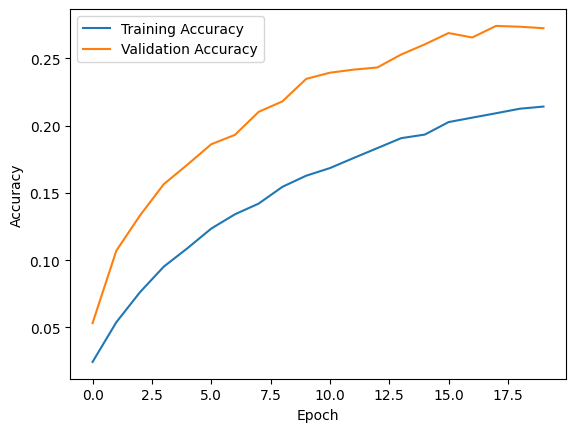

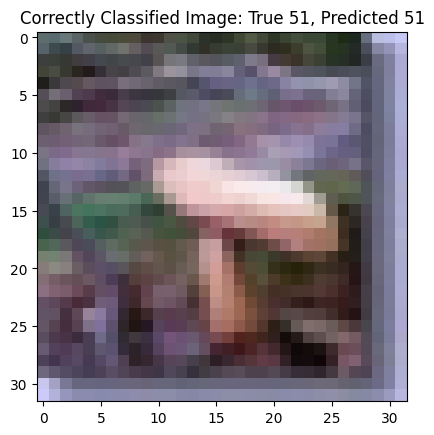

Probabilities for Correctly Classified Image: [1.56094832e-03 2.54646242e-02 9.96054709e-03 8.26575793e-03
 1.39683979e-02 9.31223854e-03 2.53049028e-03 2.50572059e-03
 1.19374124e-02 3.30649619e-03 1.22433146e-02 2.27103401e-02
 7.46363495e-03 1.29892817e-02 4.37711785e-03 9.80580971e-03
 5.25364093e-03 1.57999981e-03 5.91586810e-03 7.71557912e-03
 2.09702784e-03 1.09792734e-02 1.14077711e-02 2.86045205e-03
 5.72962337e-04 9.30467527e-03 1.48471463e-02 2.51366757e-02
 9.16004181e-03 9.39631369e-03 2.36575911e-03 2.43502739e-03
 1.30754979e-02 3.62835126e-03 1.22476984e-02 1.00622838e-02
 5.01525169e-03 1.27468947e-02 1.27182594e-02 9.32162348e-03
 2.18686517e-02 5.52293984e-03 7.92213902e-03 3.47156031e-03
 1.36619359e-02 7.30577158e-03 2.23216489e-02 1.22027617e-04
 1.44011090e-02 2.65836366e-03 6.41830917e-03 6.99612200e-02
 5.16903456e-05 7.72325729e-05 2.65838709e-02 2.04420872e-02
 1.44219224e-03 3.30530456e-03 1.62980743e-02 6.81739242e-04
 5.20053902e-04 2.75182095e-03 3.421465

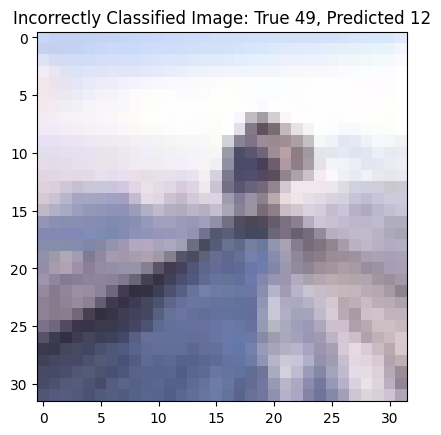

Probabilities for Incorrectly Classified Image: [1.05587460e-04 2.69456720e-03 5.02894307e-03 3.12074134e-03
 4.77005495e-03 2.42954548e-02 6.20891922e-04 2.70978850e-03
 2.14048009e-02 3.28576728e-03 4.46596649e-03 4.65805875e-03
 1.05783604e-01 1.23261651e-02 2.93726218e-04 8.90682731e-03
 2.60921963e-03 2.18284298e-02 4.54064226e-03 5.03779342e-03
 8.72843526e-03 1.09712523e-03 4.09074547e-03 2.44176090e-02
 4.67402162e-03 2.20794361e-02 5.28406305e-03 9.44369193e-03
 4.75518266e-03 9.13565513e-03 1.57641936e-02 2.51234602e-03
 9.04552825e-03 3.58662498e-03 2.45670578e-03 1.78072928e-03
 1.08331174e-03 2.69618109e-02 2.86353077e-03 2.10053399e-02
 1.93856917e-02 3.33044166e-03 1.39074924e-03 3.55862721e-04
 7.52893463e-03 5.09932870e-03 9.82366595e-03 3.33053409e-03
 9.84152406e-03 8.23609382e-02 2.68034288e-03 3.56900669e-03
 8.91697127e-04 3.15488614e-06 2.11944850e-03 1.88096948e-02
 1.09837838e-02 7.74064800e-04 1.77952107e-02 8.82143993e-03
 7.15052616e-03 2.66695791e-03 2.5730

In [16]:
import matplotlib.pyplot as plt

# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Find a correctly classified image and a misclassified image
correct_classified_indices = np.where(y_pred_classes == y_true_classes)[0]
incorrect_classified_indices = np.where(y_pred_classes != y_true_classes)[0]

correct_image_index = correct_classified_indices[0]
incorrect_image_index = incorrect_classified_indices[0]

# Plot correctly classified image
plt.imshow(x_test[correct_image_index].reshape(32, 32, 3)) # Reshape to image dimensions
plt.title(f"Correctly Classified Image: True {y_true_classes[correct_image_index]}, Predicted {y_pred_classes[correct_image_index]}")
plt.show()

# Report probabilities for correctly classified image
print(f"Probabilities for Correctly Classified Image: {y_pred_probs[correct_image_index]}")

# Plot incorrectly classified image
plt.imshow(x_test[incorrect_image_index].reshape(32, 32, 3)) # Reshape to image dimensions
plt.title(f"Incorrectly Classified Image: True {y_true_classes[incorrect_image_index]}, Predicted {y_pred_classes[incorrect_image_index]}")
plt.show()

# Report probabilities for incorrectly classified image
print(f"Probabilities for Incorrectly Classified Image: {y_pred_probs[incorrect_image_index]}")

The plot visualizes the training and validation accuracy over the epochs.
It reveals how well the model learned during training and how it generalizes to unseen data (validation set).



## Task 4: Model Enhancement (Complete or Incomplete)
### Task 4a: Implementation of at least one advanced technique

- Now it's time to improve your model. Implement at least one technique to improve your model's performance. You can use any of the techniques we have covered in class, or you can use a technique that we haven't covered. If you need inspiration, you can refer to the [Keras documentation](https://keras.io/).
- Explain the technique you used and why you chose it.
- If you used a technique that requires tuning, explain how you selected the values for the hyperparameters.

In [21]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler

# Scale the data
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train.reshape(x_train.shape[0], -1)).reshape(x_train.shape)
x_test_scaled = scaler.transform(x_test.reshape(x_test.shape[0], -1)).reshape(x_test.shape)

# Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2
)
datagen.fit(x_train_scaled)

# Model Definition (Improved Model)
cnnmodel_improved = models.Sequential()
cnnmodel_improved.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
cnnmodel_improved.add(layers.MaxPooling2D(2, 2))
cnnmodel_improved.add(layers.BatchNormalization())
cnnmodel_improved.add(layers.Conv2D(64, (3, 3), activation='relu'))
cnnmodel_improved.add(layers.MaxPooling2D(2, 2))
cnnmodel_improved.add(layers.BatchNormalization())
cnnmodel_improved.add(layers.Flatten())
cnnmodel_improved.add(layers.Dense(128, activation='relu')) #increased dense layer size
cnnmodel_improved.add(layers.Dropout(0.5))
cnnmodel_improved.add(layers.Dense(100, activation='softmax'))

# Compile the Improved Model (Adjusted Learning Rate)
cnnmodel_improved.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.00005), #reduced learning rate.
    metrics=['accuracy']
)

# Validation Data Generator (No Augmentation)
validation_datagen = ImageDataGenerator() #only scaling if scaling was done earlier.
validation_datagen.fit(x_val)
# Early Stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the Improved Model (with data augmentation)
history_improved = cnnmodel_improved.fit(datagen.flow(x_train_scaled, y_train, batch_size=32),
                                        epochs=20,
                                        validation_data=validation_datagen.flow(x_val, y_val, batch_size=32),
                                        callbacks=[early_stopping])

# Evaluate the Improved Model
loss_improved, accuracy_improved = cnnmodel_improved.evaluate(x_test_scaled, y_test, verbose=0)
print(f"Improved Model Test Accuracy: {accuracy_improved * 100:.2f}%")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 113s 88ms/step - accuracy: 0.0213 - loss: 4.9920 - val_accuracy: 0.0209 - val_loss: 4.6466
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 91s 73ms/step - accuracy: 0.0455 - loss: 4.4606 - val_accuracy: 0.0212 - val_loss: 4.6346
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 142s 73ms/step - accuracy: 0.0654 - loss: 4.2937 - val_accuracy: 0.0269 - val_loss: 4.6330
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 93s 75ms/step - accuracy: 0.0729 - loss: 4.2129 - val_accuracy: 0.0265 - val_loss: 4.6467
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 92s 74ms/step - accuracy: 0.0842 - loss: 4.1173 - val_accuracy: 0.0238 - val_loss: 4.6468
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 96s 77ms/step - accuracy: 0.0925 - loss: 4.0524 - val_accuracy: 0.0368 - val_loss: 4.7153
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 91s 73ms/step - accuracy: 0.0995 - loss: 3.9780 - val_accuracy: 0.0351 - val_loss: 4.6671
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 94s 75ms/step - accuracy: 0.1113

### Task 4b: Evaluation of the enhanced model

- Re-train your model using the same number of epochs as before.
- Compare the accuracy and other selected metric on the test set to the results you obtained before.
- As before, plot the training accuracy and validation accuracy with respect to epochs, and select an image that the model correctly classified in the test set, and an image that the model incorrectly classified in the test set. Plot the images and report the model's classification probabilities for each.

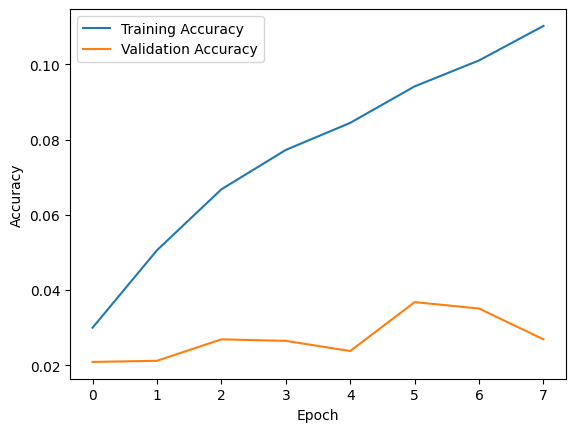

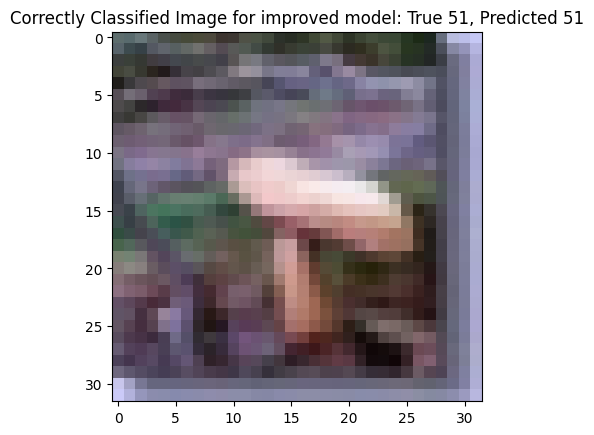

Probabilities for Correctly Classified Image for improved model: [1.56094832e-03 2.54646242e-02 9.96054709e-03 8.26575793e-03
 1.39683979e-02 9.31223854e-03 2.53049028e-03 2.50572059e-03
 1.19374124e-02 3.30649619e-03 1.22433146e-02 2.27103401e-02
 7.46363495e-03 1.29892817e-02 4.37711785e-03 9.80580971e-03
 5.25364093e-03 1.57999981e-03 5.91586810e-03 7.71557912e-03
 2.09702784e-03 1.09792734e-02 1.14077711e-02 2.86045205e-03
 5.72962337e-04 9.30467527e-03 1.48471463e-02 2.51366757e-02
 9.16004181e-03 9.39631369e-03 2.36575911e-03 2.43502739e-03
 1.30754979e-02 3.62835126e-03 1.22476984e-02 1.00622838e-02
 5.01525169e-03 1.27468947e-02 1.27182594e-02 9.32162348e-03
 2.18686517e-02 5.52293984e-03 7.92213902e-03 3.47156031e-03
 1.36619359e-02 7.30577158e-03 2.23216489e-02 1.22027617e-04
 1.44011090e-02 2.65836366e-03 6.41830917e-03 6.99612200e-02
 5.16903456e-05 7.72325729e-05 2.65838709e-02 2.04420872e-02
 1.44219224e-03 3.30530456e-03 1.62980743e-02 6.81739242e-04
 5.20053902e-04 2.75

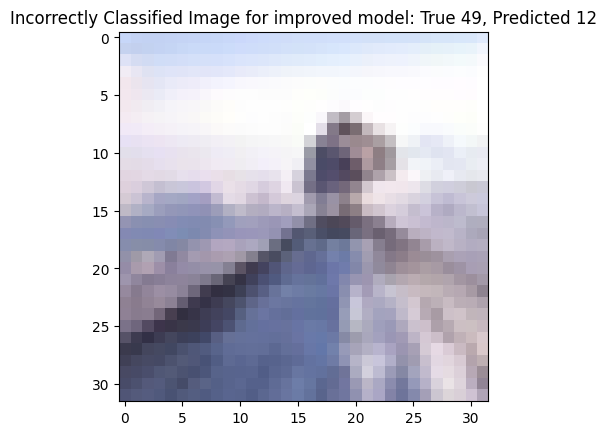

Probabilities for Incorrectly Classified Image for improved model: [1.05587460e-04 2.69456720e-03 5.02894307e-03 3.12074134e-03
 4.77005495e-03 2.42954548e-02 6.20891922e-04 2.70978850e-03
 2.14048009e-02 3.28576728e-03 4.46596649e-03 4.65805875e-03
 1.05783604e-01 1.23261651e-02 2.93726218e-04 8.90682731e-03
 2.60921963e-03 2.18284298e-02 4.54064226e-03 5.03779342e-03
 8.72843526e-03 1.09712523e-03 4.09074547e-03 2.44176090e-02
 4.67402162e-03 2.20794361e-02 5.28406305e-03 9.44369193e-03
 4.75518266e-03 9.13565513e-03 1.57641936e-02 2.51234602e-03
 9.04552825e-03 3.58662498e-03 2.45670578e-03 1.78072928e-03
 1.08331174e-03 2.69618109e-02 2.86353077e-03 2.10053399e-02
 1.93856917e-02 3.33044166e-03 1.39074924e-03 3.55862721e-04
 7.52893463e-03 5.09932870e-03 9.82366595e-03 3.33053409e-03
 9.84152406e-03 8.23609382e-02 2.68034288e-03 3.56900669e-03
 8.91697127e-04 3.15488614e-06 2.11944850e-03 1.88096948e-02
 1.09837838e-02 7.74064800e-04 1.77952107e-02 8.82143993e-03
 7.15052616e-03 2.

In [25]:
import matplotlib.pyplot as plt

# Plot training and validation accuracy
plt.plot(history_improved.history['accuracy'], label='Training Accuracy')
plt.plot(history_improved.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Find a correctly classified image and a misclassified image
correct_classified_indices = np.where(y_pred_classes == y_true_classes)[0]
incorrect_classified_indices = np.where(y_pred_classes != y_true_classes)[0]

correct_image_index = correct_classified_indices[0]
incorrect_image_index = incorrect_classified_indices[0]

# Plot correctly classified image
plt.imshow(x_test[correct_image_index].reshape(32, 32, 3)) # Reshape to image dimensions
plt.title(f"Correctly Classified Image for improved model: True {y_true_classes[correct_image_index]}, Predicted {y_pred_classes[correct_image_index]}")
plt.show()

# Report probabilities for correctly classified image
print(f"Probabilities for Correctly Classified Image for improved model: {y_pred_probs[correct_image_index]}")

# Plot incorrectly classified image
plt.imshow(x_test[incorrect_image_index].reshape(32, 32, 3)) # Reshape to image dimensions
plt.title(f"Incorrectly Classified Image for improved model: True {y_true_classes[incorrect_image_index]}, Predicted {y_pred_classes[incorrect_image_index]}")
plt.show()

# Report probabilities for incorrectly classified image
print(f"Probabilities for Incorrectly Classified Image for improved model: {y_pred_probs[incorrect_image_index]}")


### Task 4c: Discussion of the results

- Briefly discuss the results.
- Did the model's performance improve?
- Why do you think this is?
- Do you think there is room for further improvement? Why or why not?
- What other techniques might you try in the future?
- Your answer should be no more than 200 words.

# Your answer here

It doesn't seem after applying the steps that I learn over the internet thtat will improve the model. Ideal Scenario: Both training and validation accuracy should increase and plateau at a high value, with a small gap between them. This indicates good learning and generalization.

But here it seems an Overfitting case as the training accuracy is much higher than the validation accuracy, and the validation accuracy starts to decrease after a certain point. Not sure where I have gone wrong.

## Criteria

|Criteria|Complete|Incomplete|
|----|----|----|
|Task 1|The task has been completed successfully and there are no errors.|The task is still incomplete and there is at least one error.|
|Task 2|The task has been completed successfully and there are no errors.|The task is still incomplete and there is at least one error.|
|Task 3|The task has been completed successfully and there are no errors.|The task is still incomplete and there is at least one error.|
|Task 4|The task has been completed successfully and there are no errors.|The task is still incomplete and there is at least one error.|

## Submission Information

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.

### Submission Parameters:
* Submission Due Date: `HH:MM AM/PM - DD/MM/YYYY`
* The branch name for your repo should be: `assignment-1`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_1.ipynb) should be populated and should be the only change in your pull request.
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
    * Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.

Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.

If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-3-help`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.